#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [9]:
# Write your code here

from google.colab import files
uploaded = files.upload()


Saving Assignment 2 dataset.csv to Assignment 2 dataset.csv


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

Distribution of Avocado Types:
type
organic         9127
conventional    9126
Name: count, dtype: int64

Distribution of Records by Year:
year
2017    5722
2016    5616
2015    5615
2018    1300
1904       1
Name: count, dtype: int64

Top 5 Regions by Record Count:
region
WestTexNewMexico       340
Albany                 338
BaltimoreWashington    338
Boise                  338
Boston                 338
Name: count, dtype: int64

Detected Outlier (Year 1904):
            Date  AveragePrice     type            region
18250  1-21-1904          1.87  organic  WestTexNewMexico


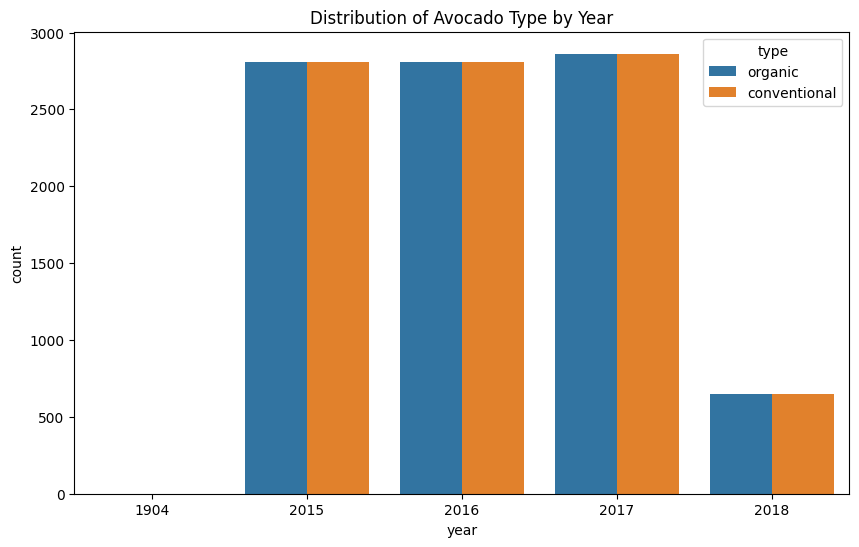

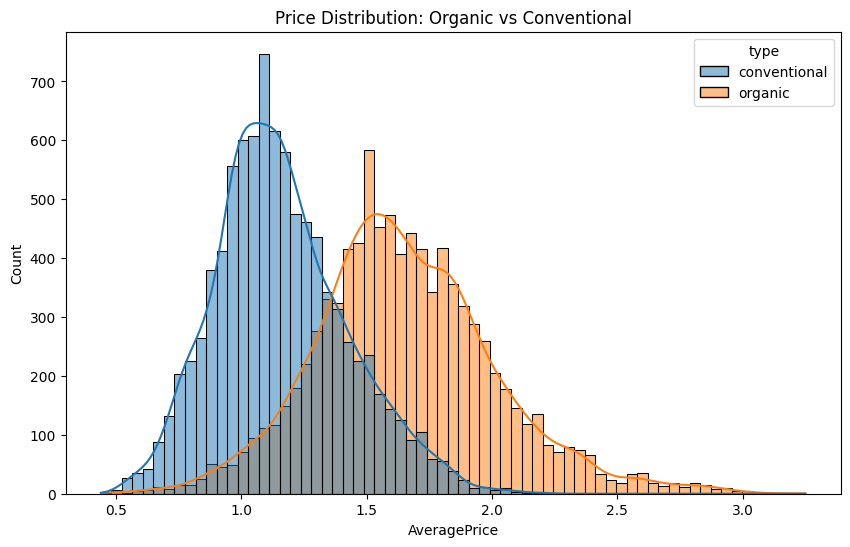

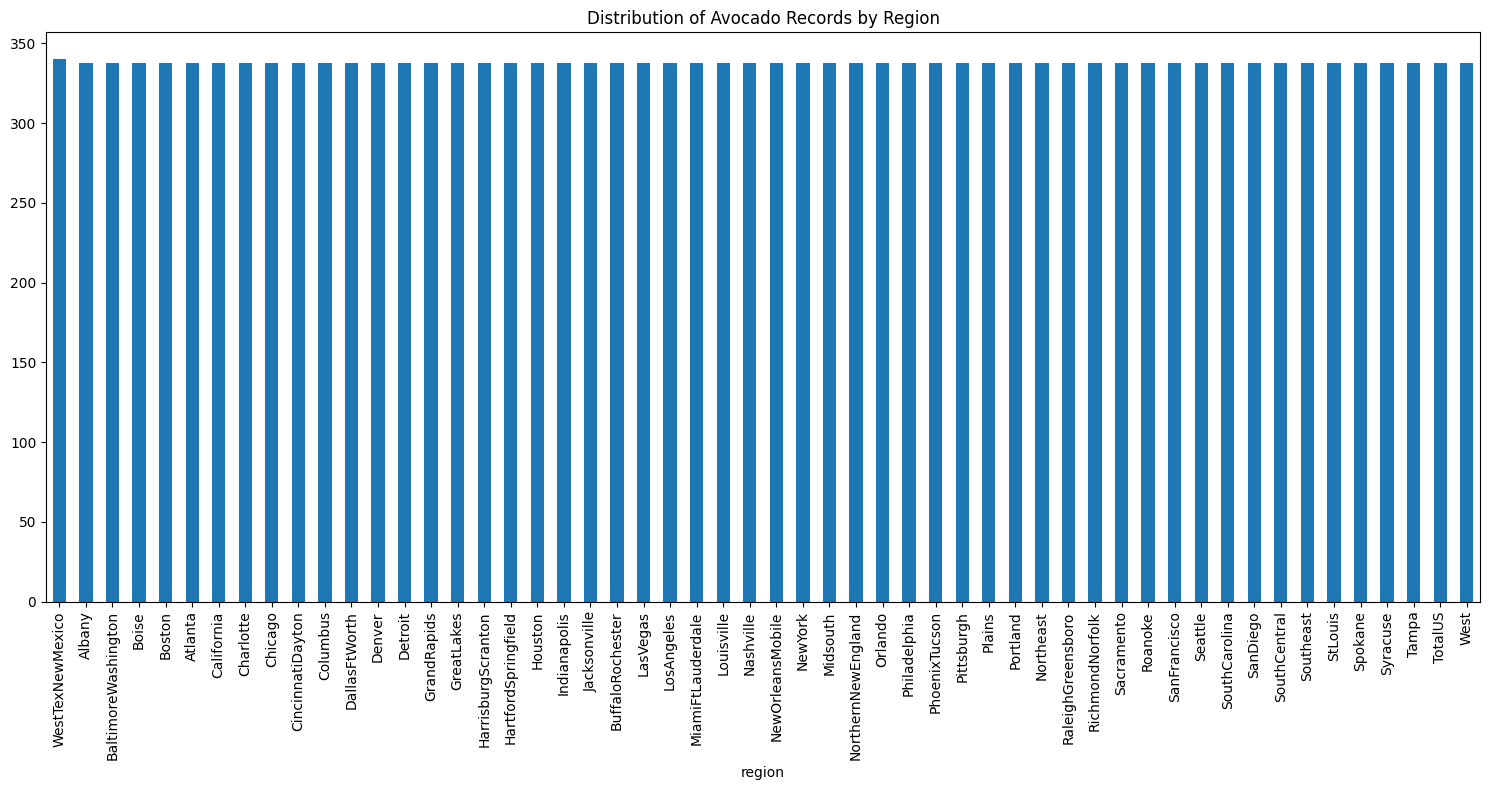

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Assignment 2 dataset.csv')

# 1. Check Class Balance: Avocado Type
type_counts = df['type'].value_counts()
print("Distribution of Avocado Types:")
print(type_counts)

# 2. Check Temporal Distribution: Year
year_counts = df['year'].value_counts()
print("\nDistribution of Records by Year:")
print(year_counts)

# 3. Check Regional Distribution
region_counts = df['region'].value_counts()
print("\nTop 5 Regions by Record Count:")
print(region_counts.head())

# 4. Check for Data Entry Errors (Outliers in Year)
outlier_year = df[df['year'] == 1904]
print("\nDetected Outlier (Year 1904):")
print(outlier_year[['Date', 'AveragePrice', 'type', 'region']])

# 5. Visualizing Distributions
# Distribution of Types by Year
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='year', hue='type')
plt.title('Distribution of Avocado Type by Year')
plt.savefig('distribution_year_type.png')

# Distribution of Average Price (Bias Check)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='AveragePrice', hue='type', kde=True)
plt.title('Price Distribution: Organic vs Conventional')
plt.savefig('price_distribution_by_type.png')

# Distribution by Region
plt.figure(figsize=(15, 8))
region_counts.plot(kind='bar')
plt.title('Distribution of Avocado Records by Region')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('distribution_region.png')



1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Assignment 2 dataset.csv')

# 1. Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {num_duplicates}")

# 2. Check for missing values in each column
missing_values = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_values)

# Display rows with missing values (optional check)
rows_with_nan = df[df.isnull().any(axis=1)]
print("\nRows with at least one missing value:")
print(rows_with_nan)


Total Duplicate Rows: 2

Missing Values per Column:
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64

Rows with at least one missing value:
       Column 1       Date  AveragePrice  Total Volume  4046    4225  4770  \
18251         8  1-28-2018          1.71      13888.04   NaN  3431.5   0.0   
18252        11   1-7-2018          1.62           NaN   NaN     NaN   NaN   

       Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18251     9264.84         NaN         NaN          0.0  organic  2018   
18252         NaN         NaN         NaN          NaN      NaN  2018   

                 region  
18251  WestTexNewMexico  
18252  WestTexNewMexico  


1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [12]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Assignment 2 dataset.csv')

# Get the number of rows and columns
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")



Number of rows: 18254
Number of columns: 14


#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [13]:
import pandas as pd

# Load the dataset
# Ensure the file is in your working directory or uploaded to Colab
df = pd.read_csv('Assignment 2 dataset.csv')

# 1. Remove the first column or “Column 1”
# This column is a redundant index that does not provide predictive value.
if 'Column 1' in df.columns:
    df = df.drop(columns=['Column 1'])
else:
    # If the name is different, remove by index position
    df = df.iloc[:, 1:]

# 2. Treat the ‘year’ variable as nominal
# Converting to 'string' (object) ensures models treat years as discrete
# categories rather than continuous numerical values.
df['year'] = df['year'].astype(str)

# Verify the changes
print("Columns in dataset:", df.columns.tolist())
print("Data type of 'year':", df['year'].dtype)
print("\nFirst 5 rows:")
print(df.head())

Columns in dataset: ['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']
Data type of 'year': object

First 5 rows:
         Date  AveragePrice  Total Volume     4046       4225    4770  \
0  12-27-2015          1.33      64236.62  1036.74   54454.85   48.16   
1  12-20-2015          1.35      54876.98   674.28   44638.81   58.33   
2  12-13-2015          0.93     118220.22   794.70  109149.67  130.50   
3   12-6-2015          1.08      78992.15  1132.00   71976.41   72.58   
4  11-29-2015          1.28      51039.60   941.48   43838.39   75.78   

   Total Bags  Small Bags  Large Bags  XLarge Bags          type  year  region  
0     8696.87     8603.62       93.25          0.0  conventional  2015  Albany  
1     9505.56     9408.07       97.49          0.0  conventional  2015  Albany  
2     8145.35     8042.21      103.14          0.0  conventional  2015  Albany  
3     5811.16     5677.40 

2.2 Check for duplicate values and remove them.

In [15]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Assignment 2 dataset.csv')

# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows before removal:", num_duplicates)

# Display duplicate rows (optional)
duplicates = df[df.duplicated()]
print("\nDuplicate rows:")
print(duplicates)

# Remove duplicate rows
df = df.drop_duplicates()

# Verify removal
num_duplicates_after = df.duplicated().sum()
print("\nNumber of duplicate rows after removal:", num_duplicates_after)

# Show new dataset shape
print("\nDataset shape after removing duplicates:", df.shape)



Number of duplicate rows before removal: 2

Duplicate rows:
       Column 1       Date  AveragePrice  Total Volume     4046     4225  \
18249        10  1-14-2018          1.93      16205.22  1527.63  2981.04   
18253         7   2-4-2018          1.63      17074.83  2046.96  1529.20   

         4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18249  727.01    10969.54    10919.54       50.00          0.0  organic  2018   
18253    0.00    13498.67    13066.82      431.85          0.0  organic  2018   

                 region  
18249  WestTexNewMexico  
18253  WestTexNewMexico  

Number of duplicate rows after removal: 0

Dataset shape after removing duplicates: (18252, 14)


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [16]:
# Check missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Count missing values per row
missing_per_row = df.isnull().sum(axis=1)

# Define threshold: if more than half the columns are missing → remove row
threshold = len(df.columns) / 2

# Remove rows with too many missing values
df = df[missing_per_row < threshold]

# Fill remaining missing numeric values with median by region
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df[col] = df.groupby('region')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Verify that missing values are handled
print("\nRemaining missing values:")
print(df.isnull().sum())


Missing values per column:
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64

Remaining missing values:
Column 1        0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


Correlation Matrix:
              Column 1  AveragePrice  Total Volume      4046      4225  \
Column 1      1.000000     -0.133099      0.014062  0.017646  0.019855   
AveragePrice -0.133099      1.000000     -0.192767 -0.208325 -0.172944   
Total Volume  0.014062     -0.192767      1.000000  0.977863  0.974181   
4046          0.017646     -0.208325      0.977863  1.000000  0.926110   
4225          0.019855     -0.172944      0.974181  0.926110  1.000000   
4770          0.041772     -0.179458      0.872203  0.833390  0.887856   
Total Bags   -0.002193     -0.177103      0.963047  0.920057  0.905788   
Small Bags    0.000369     -0.174742      0.967238  0.925280  0.916032   
Large Bags   -0.009171     -0.172953      0.880640  0.838646  0.810016   
XLarge Bags  -0.011526     -0.117604      0.747158  0.699378  0.688810   
year         -0.123915      0.064259      0.014053  0.003634 -0.005993   

                  4770  Total Bags  Small Bags  Large Bags  XLarge Bags  \
Column 1      0.

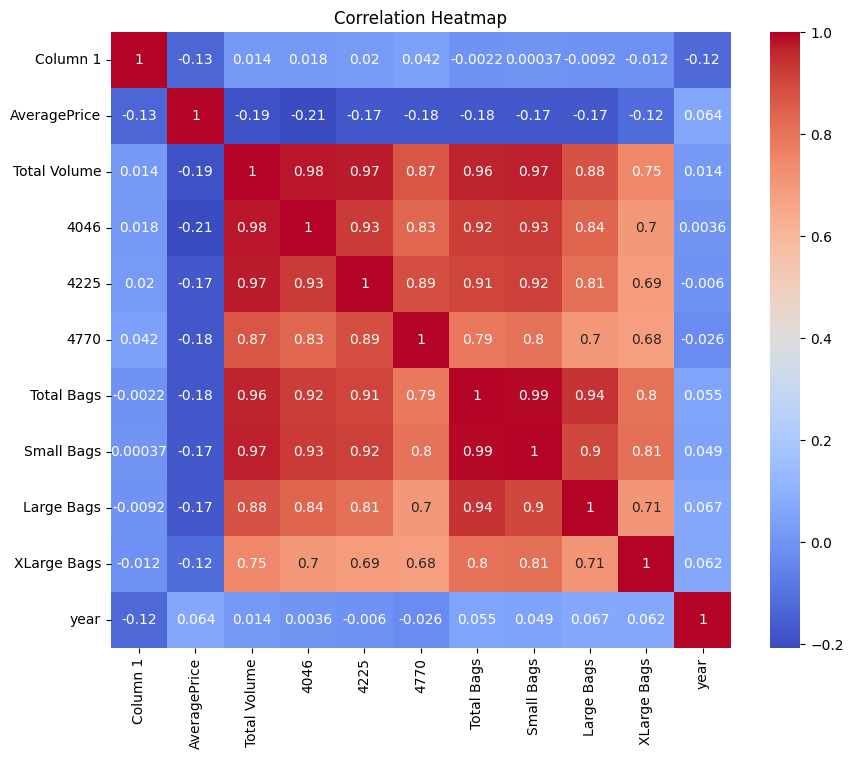

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

Continuous Variables Summary:
            Column 1  AveragePrice  Total Volume          4046          4225  \
count   18251.000000  18251.000000  1.825100e+04  1.825100e+04  1.825100e+04   
mean       24.230508      1.406020  8.505523e+05  2.929840e+05  2.951225e+05   
std        15.481073      0.402675  3.453367e+06  1.264922e+06  1.204058e+06   
min         0.000000      0.440000  8.456000e+01  0.000000e+00  0.000000e+00   
25%        10.000000      1.100000  1.084067e+04  8.543500e+02  3.008325e+03   
50%        24.000000      1.370000  1.073542e+05  8.645300e+03  2.905673e+04   
75%        38.000000      1.660000  4.329430e+05  1.110375e+05  1.501258e+05   
max        52.000000      3.250000  6.250565e+07  2.274362e+07  2.047057e+07   
median     24.000000      1.370000  1.073542e+05  8.645300e+03  2.905673e+04   

                4770    Total Bags    Small Bags    Large Bags    XLarge Bags  \
count   1.825100e+04  1.825100e+04  1.825100e+04  1.825100e+04   18251.000000   
mean   

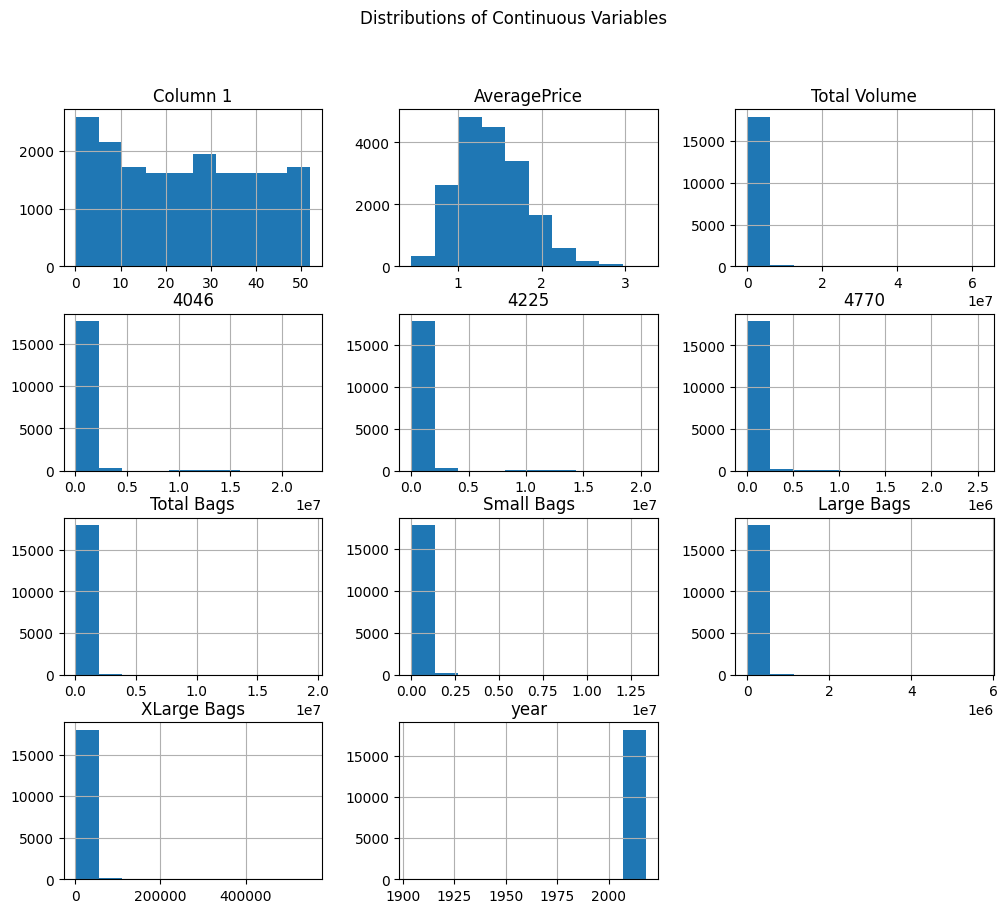


Categorical Variables Unique Values:

Date:
['12-27-2015' '12-20-2015' '12-13-2015' '12-6-2015' '11-29-2015'
 '11-22-2015' '11-15-2015' '11-8-2015' '11-1-2015' '10-25-2015'
 '10-18-2015' '10-11-2015' '10-4-2015' '9-27-2015' '9-20-2015' '9-13-2015'
 '9-6-2015' '8-30-2015' '8-23-2015' '8-16-2015' '8-9-2015' '8-2-2015'
 '7-26-2015' '7-19-2015' '7-12-2015' '7-5-2015' '6-28-2015' '6-21-2015'
 '6-14-2015' '6-7-2015' '5-31-2015' '5-24-2015' '5-17-2015' '5-10-2015'
 '5-3-2015' '4-26-2015' '4-19-2015' '4-12-2015' '4-5-2015' '3-29-2015'
 '3-22-2015' '3-15-2015' '3-8-2015' '3-1-2015' '2-22-2015' '2-15-2015'
 '2-8-2015' '2-1-2015' '1-25-2015' '1-18-2015' '1-11-2015' '1-4-2015'
 '12-25-2016' '12-18-2016' '12-11-2016' '12-4-2016' '11-27-2016'
 '11-20-2016' '11-13-2016' '11-6-2016' '10-30-2016' '10-23-2016'
 '10-16-2016' '10-9-2016' '10-2-2016' '9-25-2016' '9-18-2016' '9-11-2016'
 '9-4-2016' '8-28-2016' '8-21-2016' '8-14-2016' '8-7-2016' '7-31-2016'
 '7-24-2016' '7-17-2016' '7-10-2016' '7-3-2016' '6

In [18]:
# Separate numeric and categorical variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])
categorical_df = df.select_dtypes(include=['object'])

# Continuous variables summary
print("Continuous Variables Summary:")
summary = numeric_df.describe()

# Add median to summary
summary.loc['median'] = numeric_df.median()
print(summary)

# Show distributions (histograms)
numeric_df.hist(figsize=(12, 10))
plt.suptitle("Distributions of Continuous Variables")
plt.show()

# Categorical variables: unique values
print("\nCategorical Variables Unique Values:")
for col in categorical_df.columns:
    print(f"\n{col}:")
    print(categorical_df[col].unique())


3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [19]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Find earliest date
earliest_date = df['Date'].min()
print("Earliest recorded date:", earliest_date)

# Check for records up to 2010
records_before_2010 = df[df['Date'].dt.year <= 2010]
print("Number of records from earliest date to 2010:", len(records_before_2010))



Earliest recorded date: 1904-01-21 00:00:00
Number of records from earliest date to 2010: 1


3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [20]:
# Find row with highest average price
max_price_row = df.loc[df['AveragePrice'].idxmax()]

print("Highest Average Price:", max_price_row['AveragePrice'])
print("Region:", max_price_row['region'])



Highest Average Price: 3.25
Region: SanFrancisco


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [21]:
# Find row with highest total volume
max_volume_row = df.loc[df['Total Volume'].idxmax()]

print("Highest Total Volume:", max_volume_row['Total Volume'])
print("Region:", max_volume_row['region'])


Highest Total Volume: 62505646.52
Region: TotalUS
